# Libreria


In [401]:
import struct
import os
# Manejo de datos
import pandas as pd
import numpy as np


# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Optuna
import optuna

# Preprocesamiento de datos
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

# Copy
import copy

# Manejo de desbalance de clases
from imblearn.over_sampling import SMOTE


# Construcción de la Red Neuronal (PyTorch)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Métricas de evaluación
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             classification_report, ConfusionMatrixDisplay,fbeta_score)

# Configuración visual para los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Verificar si hay GPU disponible para PyTorch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Librerías importadas. PyTorch utilizará el dispositivo: {device}")

Librerías importadas. PyTorch utilizará el dispositivo: cpu


In [402]:
csv_path = "./superstore.csv"

if not os.path.exists(csv_path):
    zip_path = "archive.zip"
    !gdown 1CZOPvXzpA48GC2WVsmA5hZvyQugDQ6sQ -O {zip_path}
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall("Problema1")
    os.remove(zip_path)
else:
    print("Dataset ya existe, omitiendo descarga.")

Dataset ya existe, omitiendo descarga.


# EDA

In [403]:
dataset = pd.read_csv("./superstore.csv", encoding='Latin-1')

data = dataset.copy()

data.columns = data.columns.str.replace(' ', '_')

data.drop(columns=['Row_ID', 'Order_ID', 'Customer_ID', 'Product_ID', 'Customer_Name', 'Product_Name', 'Country', 'City', 'Postal_Code', 'State'], inplace=True)

data.head(5)

,Order_Date,Ship_Date,Ship_Mode,Segment,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,11/8/2016,11/11/2016,Second Class,Consumer,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,11/8/2016,11/11/2016,Second Class,Consumer,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,6/12/2016,6/16/2016,Second Class,Corporate,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,10/11/2015,10/18/2015,Standard Class,Consumer,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,10/11/2015,10/18/2015,Standard Class,Consumer,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [404]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order_Date    9994 non-null   str    
 1   Ship_Date     9994 non-null   str    
 2   Ship_Mode     9994 non-null   str    
 3   Segment       9994 non-null   str    
 4   Region        9994 non-null   str    
 5   Category      9994 non-null   str    
 6   Sub-Category  9994 non-null   str    
 7   Sales         9994 non-null   float64
 8   Quantity      9994 non-null   int64  
 9   Discount      9994 non-null   float64
 10  Profit        9994 non-null   float64
dtypes: float64(3), int64(1), str(7)
memory usage: 859.0 KB


In [405]:
print(data.isnull().sum(), data.duplicated().sum())

Order_Date      0
Ship_Date       0
Ship_Mode       0
Segment         0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64 1


In [406]:
data.describe()

,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896
std,623.245101,2.225110,0.206452,234.260108
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.728750
50%,54.490000,3.000000,0.200000,8.666500
75%,209.940000,5.000000,0.200000,29.364000
max,22638.480000,14.000000,0.800000,8399.976000


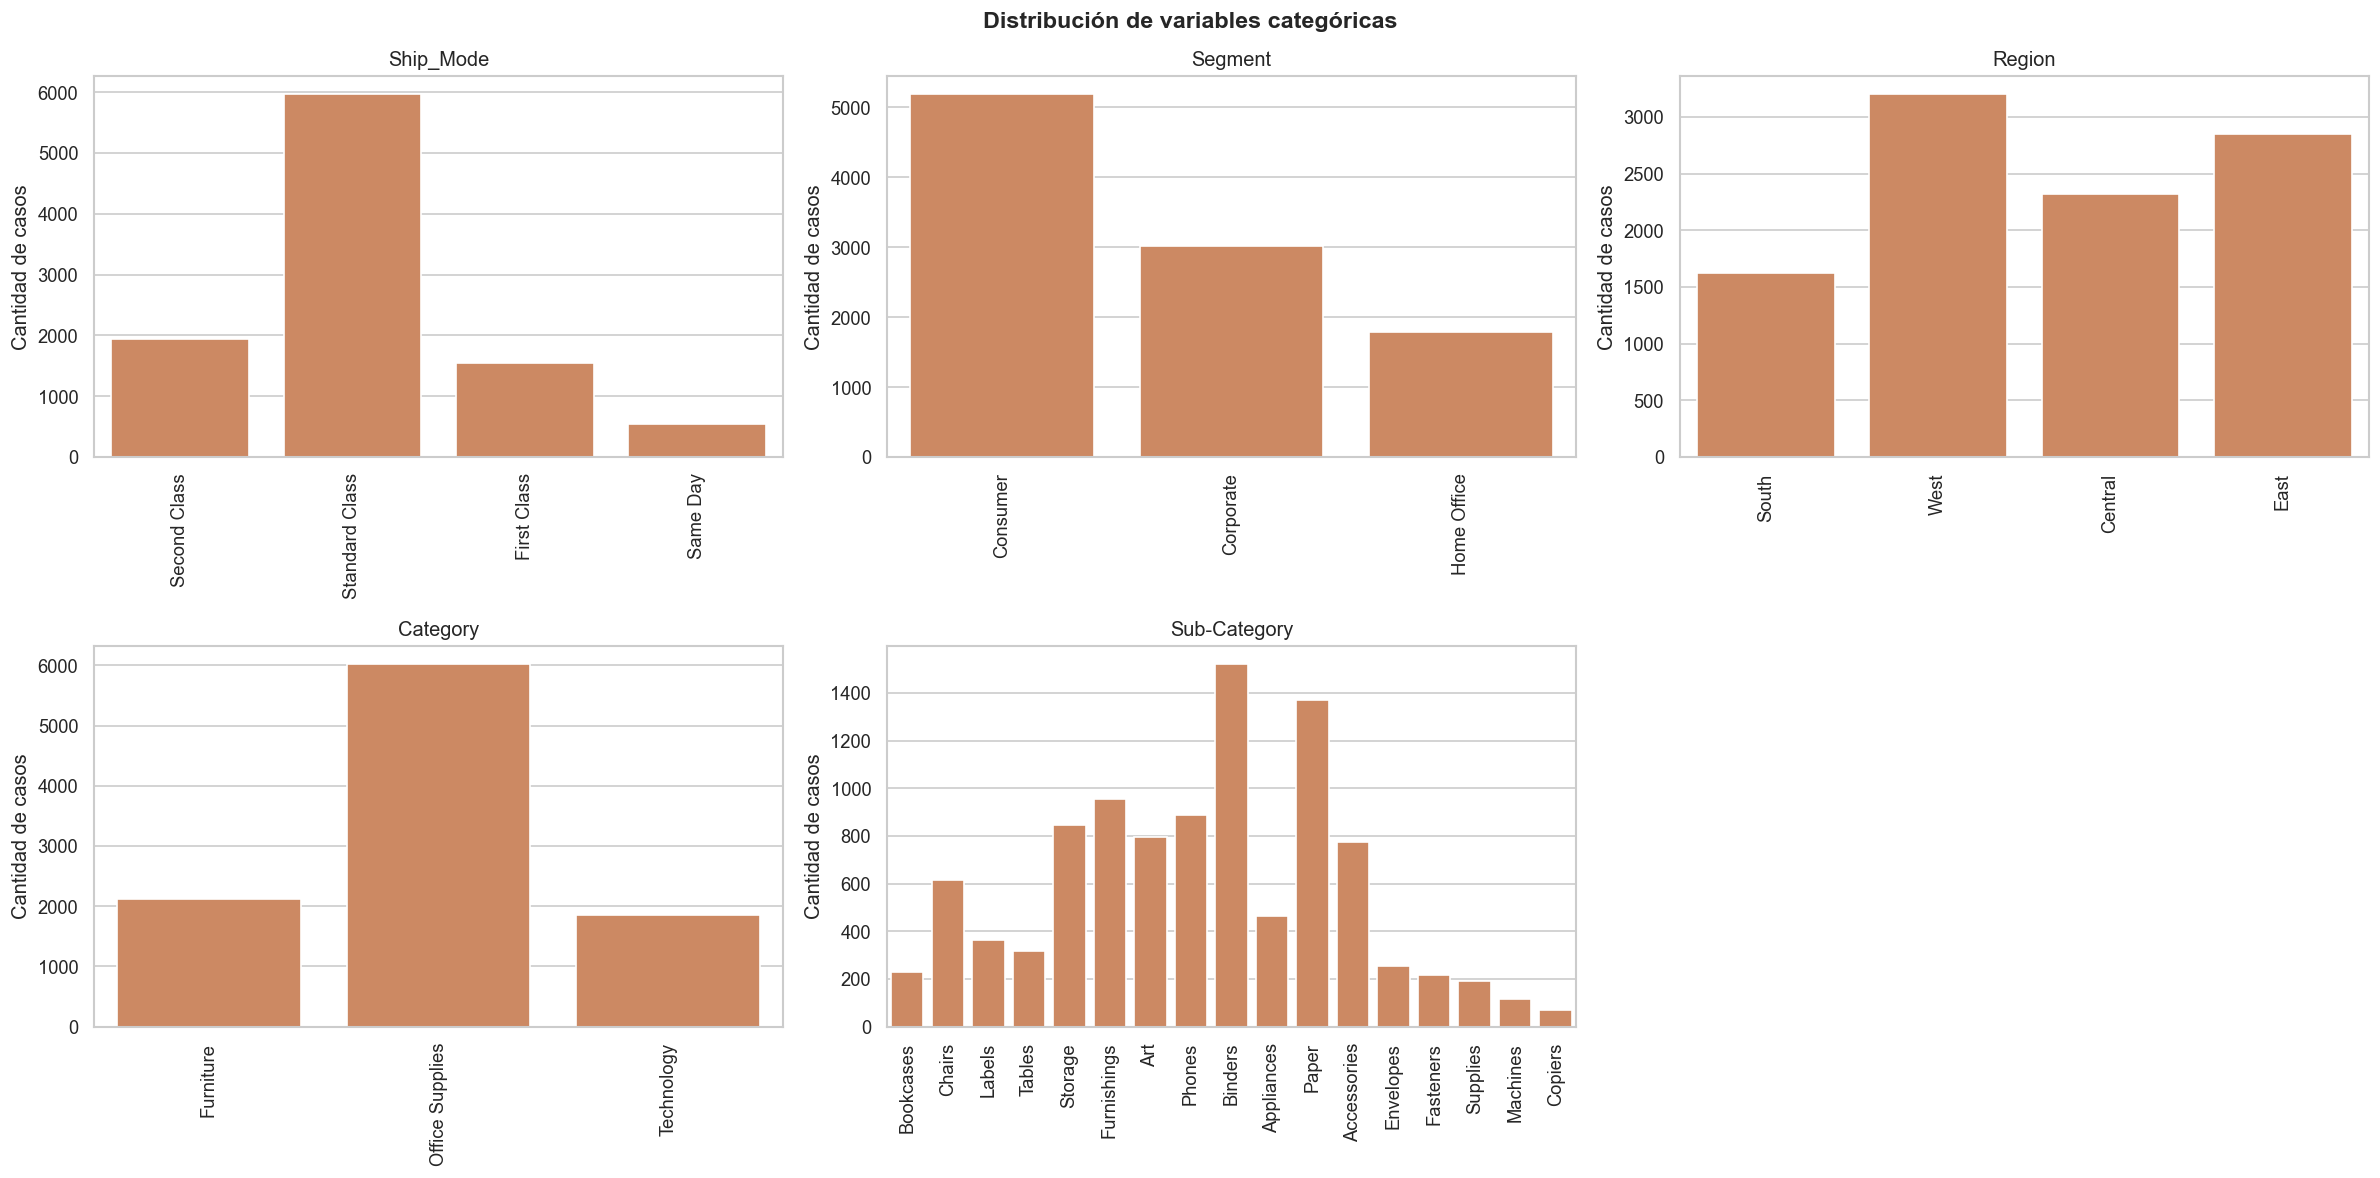

In [407]:
cols_categoricas = ['Ship_Mode', 'Segment', 'Region', 'Category', 'Sub-Category']

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle("Distribución de variables categóricas", fontsize=14, fontweight='bold')
axes = axes.flatten()

for ax, col in zip(axes, cols_categoricas):
    sns.countplot(
        data=data[cols_categoricas],
        x=col,
        color='#DD8452',
        ax=ax
    )
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Cantidad de casos")
    ax.tick_params(axis='x', rotation=90)

axes[-1].set_visible(False)

plt.tight_layout()
plt.show()


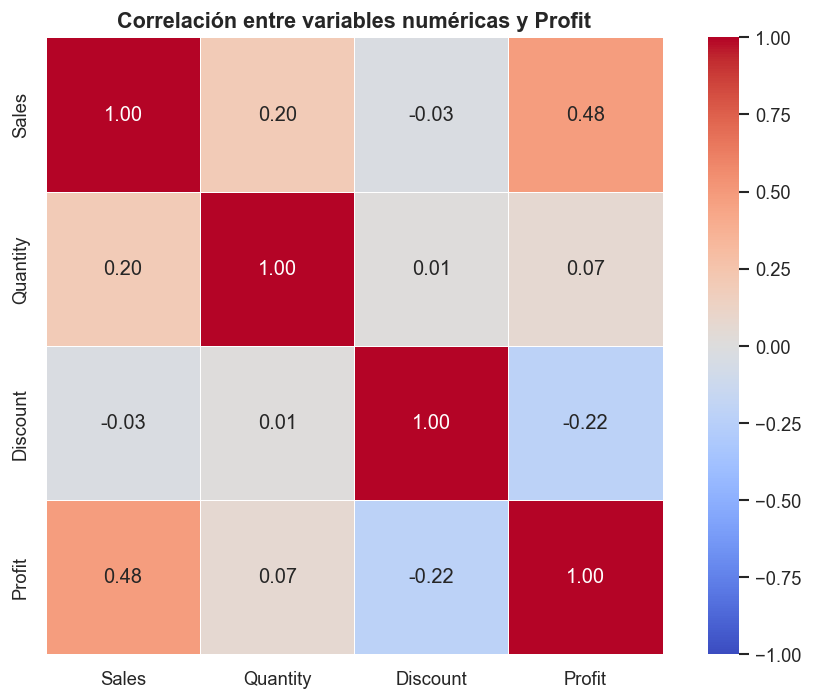

In [408]:
cols_numericas = ['Sales', 'Quantity', 'Discount', 'Profit']

corr_matrix = data[cols_numericas].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True
)
plt.title("Correlación entre variables numéricas y Profit", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

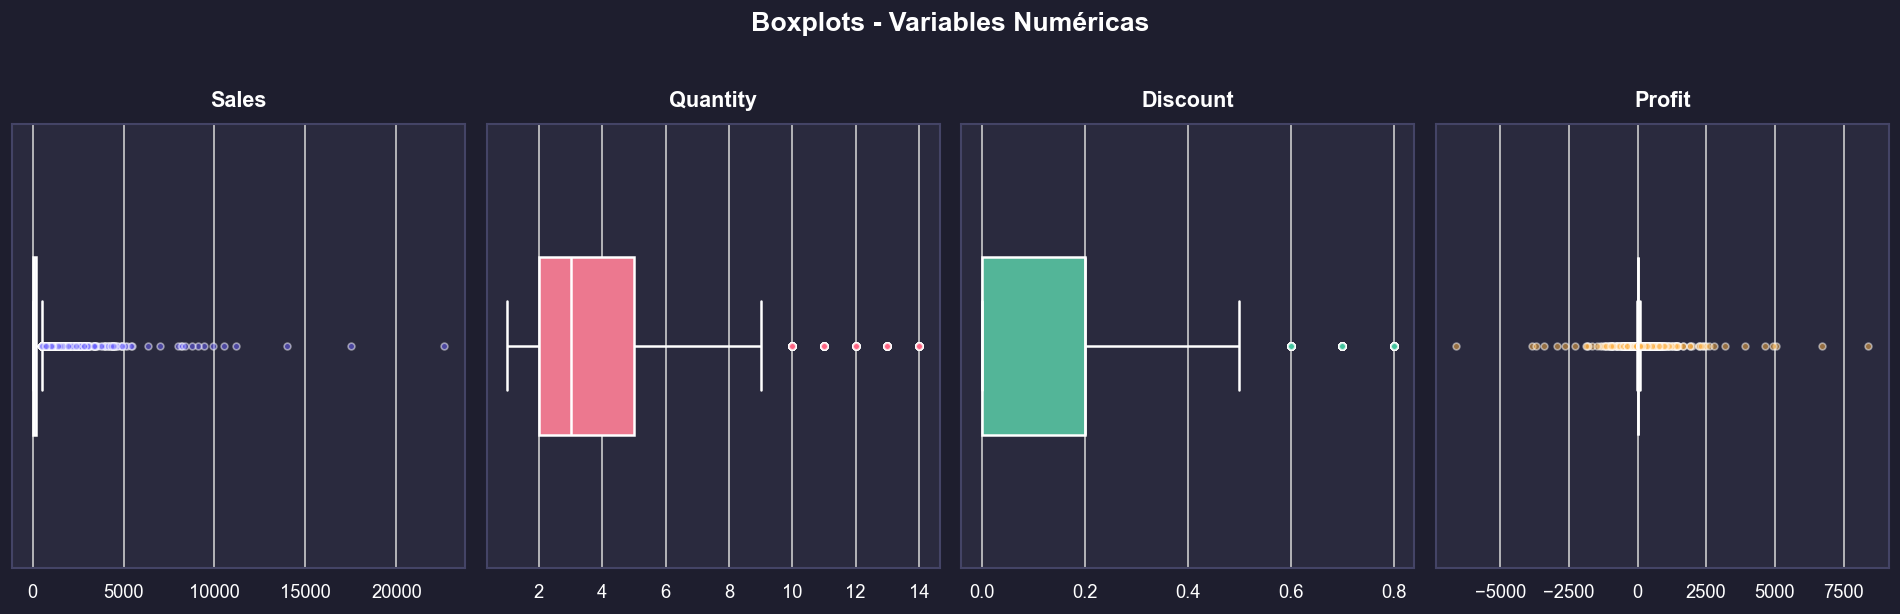

In [409]:
palette = ["#6C63FF", "#FF6584", "#43C59E", "#FFB347", "#4FC3F7"]

n_cols = 4
n_rows = (len(cols_numericas) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 5))
fig.patch.set_facecolor("#1E1E2E")
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    ax = axes[i]
    color = palette[i % len(palette)]

    sns.boxplot(
        x=data[col].dropna(),
        ax=ax,
        color=color,
        linecolor="white",
        linewidth=1.5,
        flierprops=dict(marker="o", markerfacecolor=color, markersize=4, alpha=0.5),
        width=0.4
    )

    ax.set_facecolor("#2A2A3E")
    ax.set_title(col, color="white", fontsize=13, fontweight="bold", pad=10)
    ax.set_xlabel("")
    ax.tick_params(colors="white")
    ax.yaxis.label.set_color("white")
    for spine in ax.spines.values():
        spine.set_edgecolor("#444466")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Boxplots - Variables Numéricas", color="white", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


# Preprocesamiento

In [410]:
data['Order_Date'] = pd.to_datetime(data['Order_Date'], dayfirst=True, format='mixed')  
data['Year'] = data['Order_Date'].dt.year
data['Month'] = data['Order_Date'].dt.month
data['YearMonth'] = data['Order_Date'].dt.to_period('M')

# Profit total por mes
profit_mensual = data.groupby('YearMonth')['Profit'].sum().reset_index()
profit_mensual['YearMonth'] = profit_mensual['YearMonth'].astype(str)

data.head(5)

,Order_Date,Ship_Date,Ship_Mode,Segment,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,Year,Month,YearMonth
0,2016-08-11,11/11/2016,Second Class,Consumer,South,Furniture,Bookcases,261.9600,2,0.00,41.9136,2016,8,2016-08
1,2016-08-11,11/11/2016,Second Class,Consumer,South,Furniture,Chairs,731.9400,3,0.00,219.5820,2016,8,2016-08
2,2016-12-06,6/16/2016,Second Class,Corporate,West,Office Supplies,Labels,14.6200,2,0.00,6.8714,2016,12,2016-12
3,2015-11-10,10/18/2015,Standard Class,Consumer,South,Furniture,Tables,957.5775,5,0.45,-383.0310,2015,11,2015-11
4,2015-11-10,10/18/2015,Standard Class,Consumer,South,Office Supplies,Storage,22.3680,2,0.20,2.5164,2015,11,2015-11


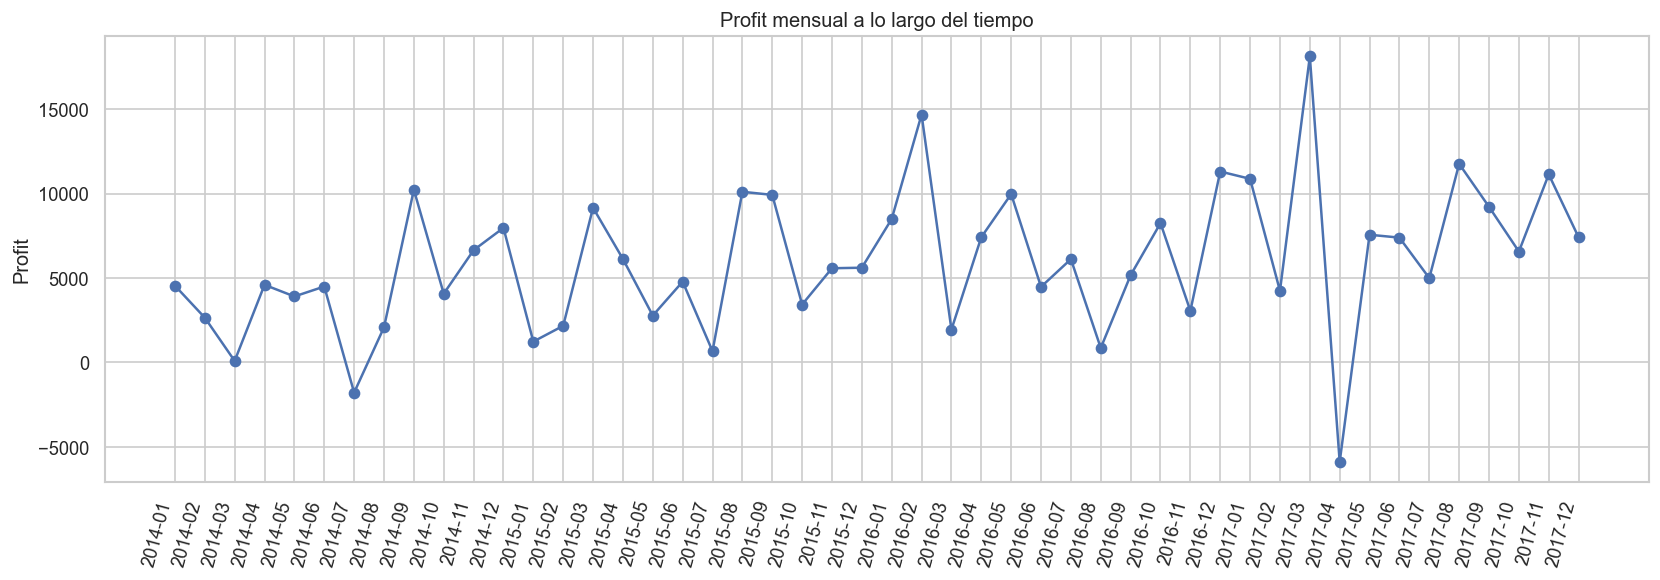

In [411]:
plt.figure(figsize=(14, 5))
plt.plot(profit_mensual['YearMonth'], profit_mensual['Profit'], marker='o', linewidth=1.5)
plt.xticks(rotation=75, ha='right')
plt.title('Profit mensual a lo largo del tiempo')
plt.ylabel('Profit')
plt.tight_layout()
plt.show()

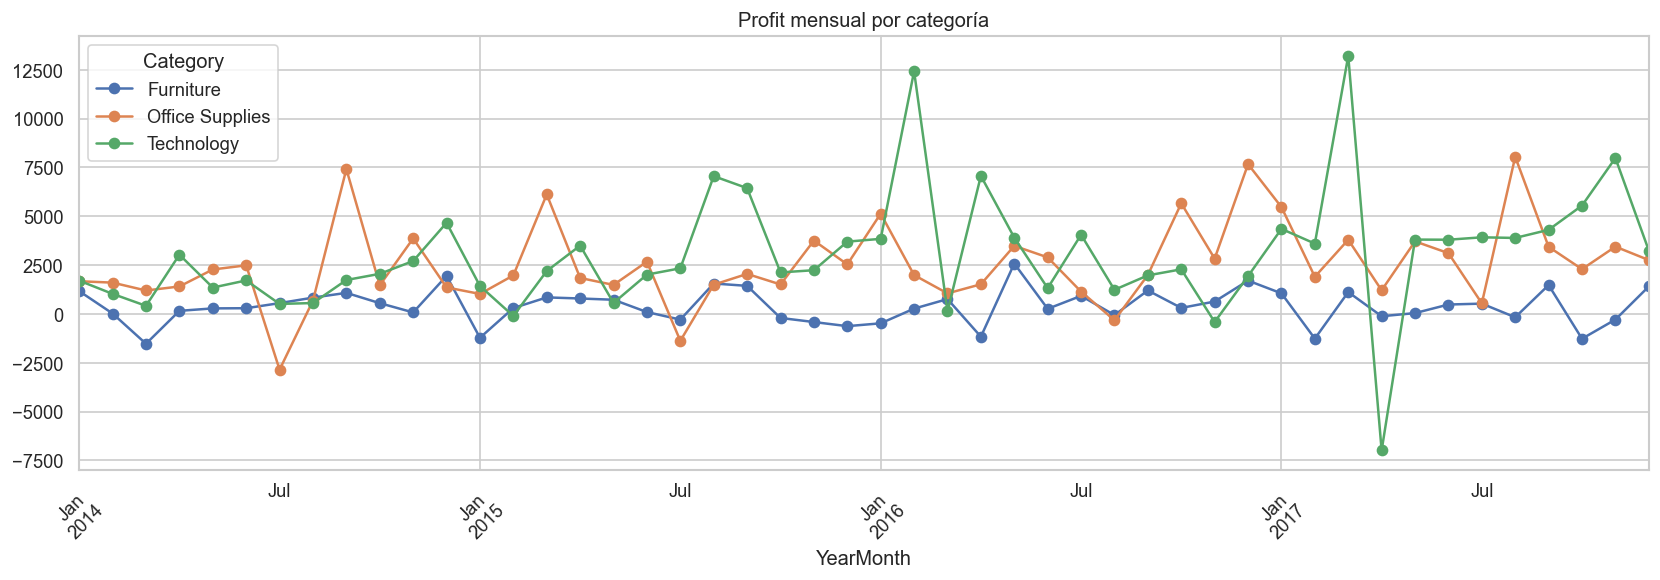

In [412]:
profit_cat = data.groupby(['YearMonth', 'Category'])['Profit'].sum().unstack()
profit_cat.plot(figsize=(14, 5), marker='o', linewidth=1.5)
plt.xticks(rotation=45)
plt.title('Profit mensual por categoría')
plt.tight_layout()
plt.show()

*Codificación de variables*

In [413]:
data['month_sin'] = np.sin(2 * np.pi * data['Month'] / 12)
data['month_cos'] = np.cos(2 * np.pi * data['Month'] / 12)
data.drop(columns=['Month', 'Order_Date', 'Ship_Date', 'YearMonth'], inplace=True)

In [414]:
encoder = OneHotEncoder(drop='first', dtype=int, sparse_output=False)

encoded = encoder.fit_transform(data[cols_categoricas])

encoded_data = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(cols_categoricas))

data = data.drop(columns=cols_categoricas).reset_index(drop=True)
data = pd.concat([data, encoded_data], axis=1)


*División en train y test*

In [415]:
X = data.drop('Profit', axis=1)
y = data['Profit']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [416]:
cols_escalar = ['Sales', 'Quantity', 'Discount']

scaler = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Escalamos X
X_train_scaled[cols_escalar] = scaler.fit_transform(X_train[cols_escalar])
X_test_scaled[cols_escalar] = scaler.transform(X_test[cols_escalar])

# Escalamos la y
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

#
N_DIM = X_train_scaled.shape[1]

In [417]:
X_test_scaled, X_val_scaled, y_test_scaled, y_val_scaled = train_test_split(X_test_scaled, y_test_scaled, test_size=0.5, random_state=42)

In [418]:
print(f"   Train: {X_train_scaled.shape[0]} ejemplos ({X_train_scaled.shape[0]/len(data)*100:.0f}%)")
print(f"   Test:  {X_test_scaled.shape[0]} ejemplos ({X_test_scaled.shape[0]/len(data)*100:.0f}%)")
print(f"   Test:  {X_val_scaled.shape[0]} ejemplos ({X_val_scaled.shape[0]/len(data)*100:.0f}%)")

   Train: 6995 ejemplos (70%)
   Test:  1499 ejemplos (15%)
   Test:  1500 ejemplos (15%)


# Entrenamiento y curvas de aprendizaje

In [419]:
class RegresionNet_PyTorch(nn.Module):
    def __init__(self, input_dim=32, dropout_rate=0.2):
        super(RegresionNet_PyTorch, self).__init__()

        # Capa oculta 1: de input_dim features a 64 neuronas
        self.capa1 = nn.Linear(input_dim, 64)
        self.bn1   = nn.BatchNorm1d(64)     # normalización de batch
        self.act1  = nn.ReLU()              # activación no lineal
        self.drop1 = nn.Dropout(dropout_rate)  # regularización

        # Capa oculta 2: de 64 a 32 neuronas
        self.capa2 = nn.Linear(64, 32)
        self.bn2   = nn.BatchNorm1d(32)
        self.act2  = nn.ReLU()
        self.drop2 = nn.Dropout(dropout_rate)

        # Capa de salida: de 32 a 1 neurona, SIN activación (lineal)
        self.salida = nn.Linear(32, 1)

        self._inicializar_pesos()

    def _inicializar_pesos(self):
        """Aplica la inicialización de He a todas las capas lineales."""
        for modulo in self.modules():
            if isinstance(modulo, nn.Linear):
                nn.init.kaiming_normal_(modulo.weight, mode='fan_in', nonlinearity='relu')
                # El bias se inicializa en 0 (práctica estándar)
                nn.init.zeros_(modulo.bias)

    def forward(self, x):
        """
        forward: define el flujo de datos a través de la red.
        PyTorch llama a este método automáticamente cuando hacemos model(x).
        La propagación es: x → z1 → bn → relu → drop → z2 → bn → relu → drop → ŷ
        """
        # Capa 1: combinación lineal → normalización → activación → dropout
        x = self.capa1(x)    # z^[1] = W^[1] · x + b^[1]
        x = self.bn1(x)      # normalizar activaciones del batch
        x = self.act1(x)     # a^[1] = ReLU(z^[1])
        x = self.drop1(x)    # desactivar neuronas aleatoriamente

        # Capa 2: mismo patrón
        x = self.capa2(x)    # z^[2] = W^[2] · a^[1] + b^[2]
        x = self.bn2(x)
        x = self.act2(x)     # a^[2] = ReLU(z^[2])
        x = self.drop2(x)

        # Capa de salida: combinación lineal SIN activación
        x = self.salida(x)   # ŷ = W^[3] · a^[2] + b^[3]  (escalar)

        # squeeze(1) convierte de forma (batch, 1) a (batch,)
        return x.squeeze(1)


# Instanciar el modelo
modelo_reg_pt = RegresionNet_PyTorch(input_dim=N_DIM, dropout_rate=0.2)
print("\n🏗️  Arquitectura del modelo PyTorch para Regresión:")
print(modelo_reg_pt)

# Contar parámetros entrenables
total_params = sum(p.numel() for p in modelo_reg_pt.parameters() if p.requires_grad)
print(f"\n   Total de parámetros entrenables: {total_params:,}")
print(f"   Desglose por capa:")
for nombre, param in modelo_reg_pt.named_parameters():
    if param.requires_grad:
        forma_str = str(list(param.shape))
        print(f"     {nombre:30s} → {forma_str:20s} = {param.numel():5d} params")


🏗️  Arquitectura del modelo PyTorch para Regresión:
RegresionNet_PyTorch(
  (capa1): Linear(in_features=32, out_features=64, bias=True)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act1): ReLU()
  (drop1): Dropout(p=0.2, inplace=False)
  (capa2): Linear(in_features=64, out_features=32, bias=True)
  (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act2): ReLU()
  (drop2): Dropout(p=0.2, inplace=False)
  (salida): Linear(in_features=32, out_features=1, bias=True)
)

   Total de parámetros entrenables: 4,417
   Desglose por capa:
     capa1.weight                   → [64, 32]             =  2048 params
     capa1.bias                     → [64]                 =    64 params
     bn1.weight                     → [64]                 =    64 params
     bn1.bias                       → [64]                 =    64 params
     capa2.weight                   → [32, 64]             =  2048 params
     cap

In [420]:
def entrenar_pytorch_regresion(modelo, X_train, y_train, X_test, y_test, epochs=200, batch_size=32, lr=1e-3, weight_decay=1e-4, patience=15):
    """
    Función de entrenamiento completa para regresión en PyTorch.
    Implementa el ciclo: Forward → Loss → Backward → Update
    con early stopping y registro de métricas por época.
    """
    X_tr = torch.tensor(X_train.values, dtype=torch.float32)
    y_tr = torch.tensor(y_train, dtype=torch.float32)
    X_te = torch.tensor(X_test.values,  dtype=torch.float32)
    y_te = torch.tensor(y_test,  dtype=torch.float32)


    dataset_train = TensorDataset(X_tr, y_tr)
    loader_train  = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)


    criterio = nn.MSELoss()


    optimizador = optim.Adam(modelo.parameters(), lr=lr, weight_decay=weight_decay)

    # Variables de seguimiento 
    historial = {'train_loss': [], 'test_loss': []}
    mejor_loss_val  = float('inf')
    mejor_pesos     = None
    epocas_sin_mejora = 0

    print(f"\n🚀 Iniciando entrenamiento PyTorch (Regresión)")
    print(f"   Épocas máximas: {epochs} | Batch size: {batch_size} | LR: {lr}")
    print(f"   Paciencia early stopping: {patience} épocas")
    print(f"   Batches por época: {len(loader_train)}")
    print("-" * 55)

    for epoca in range(epochs):

        modelo.train()
        loss_train_total = 0.0

        for X_batch, y_batch in loader_train:

            y_pred = modelo(X_batch)
            loss = criterio(y_pred, y_batch)
            
            optimizador.zero_grad()
            loss.backward()
            optimizador.step()

            loss_train_total += loss.item()

        loss_train_promedio = loss_train_total / len(loader_train)

        
        modelo.eval()

        
        with torch.no_grad():
            y_pred_test = modelo(X_te)
            loss_test = criterio(y_pred_test, y_te).item()

        historial['train_loss'].append(loss_train_promedio)
        historial['test_loss'].append(loss_test)

        
        if loss_test < mejor_loss_val:
            mejor_loss_val = loss_test

            mejor_pesos = {k: v.clone() for k, v in modelo.state_dict().items()}
            epocas_sin_mejora = 0
        else:
            epocas_sin_mejora += 1

        if (epoca + 1) % 25 == 0:
            print(f"   Época {epoca+1:4d}/{epochs} | "
                  f"Loss train: {loss_train_promedio:.4f} | "
                  f"Loss test: {loss_test:.4f} | "
                  f"Sin mejora: {epocas_sin_mejora}/{patience}")

        if epocas_sin_mejora >= patience:
            print(f"\n   ⏹️  Early stopping en época {epoca+1}")
            print(f"   Mejor loss de validación: {mejor_loss_val:.4f}")
            break

    # Restaurar los mejores pesos
    if mejor_pesos is not None:
        modelo.load_state_dict(mejor_pesos)
        print(f"\n   ✅ Mejores pesos restaurados (loss val: {mejor_loss_val:.4f})")

    return historial


# Ejecutar el entrenamiento
historial_reg_pt = entrenar_pytorch_regresion(modelo_reg_pt, X_train_scaled, y_train_scaled, X_test_scaled, y_test_scaled, 
                                            epochs=300, batch_size=32, lr=1e-3, weight_decay=1e-4, patience=20)


🚀 Iniciando entrenamiento PyTorch (Regresión)
   Épocas máximas: 300 | Batch size: 32 | LR: 0.001
   Paciencia early stopping: 20 épocas
   Batches por época: 219
-------------------------------------------------------


c:\Users\nicom\Documents\Antigravity\AA2_TP1_Grupo2\.venv\Lib\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([32, 1])) that is different to the input size (torch.Size([32])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
c:\Users\nicom\Documents\Antigravity\AA2_TP1_Grupo2\.venv\Lib\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([19, 1])) that is different to the input size (torch.Size([19])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
c:\Users\nicom\Documents\Antigravity\AA2_TP1_Grupo2\.venv\Lib\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([1499, 1])) that is different to the input size (torch.Size([1499])). This will likely 

   Época   25/300 | Loss train: 1.0013 | Loss test: 0.5577 | Sin mejora: 2/20
   Época   50/300 | Loss train: 0.9916 | Loss test: 0.8225 | Sin mejora: 20/20

   ⏹️  Early stopping en época 50
   Mejor loss de validación: 0.5565

   ✅ Mejores pesos restaurados (loss val: 0.5565)



📈 Evaluación del Modelo PyTorch (Regresión):
   MSE:  76504.55
   RMSE: 276.59  (en las unidades originales del target)
   R²:   -0.0044  (1.0 = perfecto, 0 = sin información)


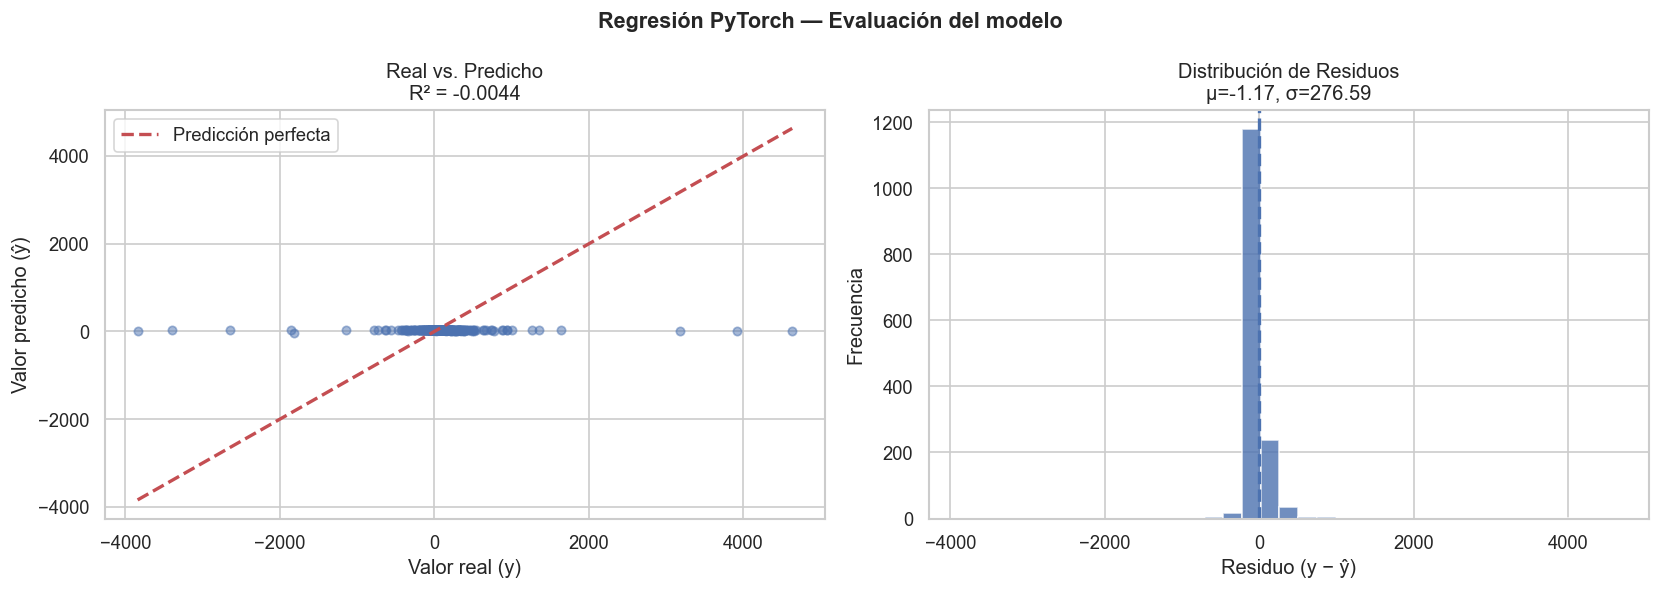

[Figura guardada: reg_04_evaluacion_pytorch.png]


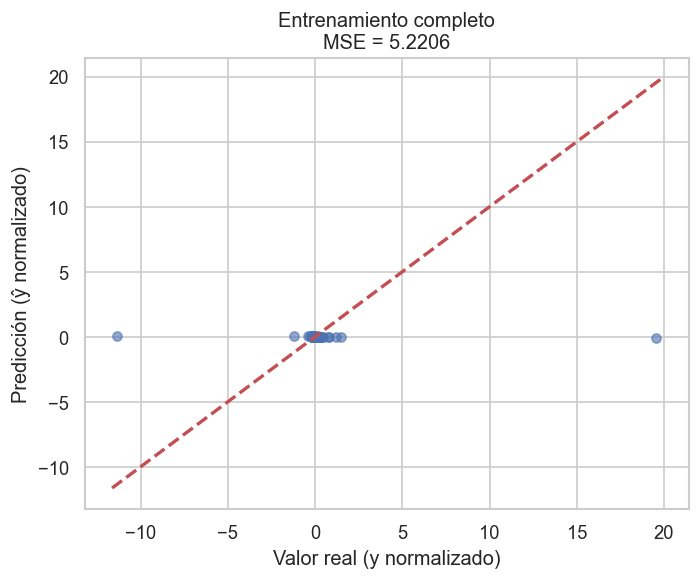

In [422]:
modelo_reg_pt.eval()

with torch.no_grad():

    X_val_np = X_val_scaled.values if hasattr(X_val_scaled, "values") else X_val_scaled
    y_val_np = y_val_scaled.values if hasattr(y_val_scaled, "values") else y_val_scaled

    X_val_np = np.asarray(X_val_np).astype(np.float32)
    y_val_np = np.asarray(y_val_np).astype(np.float32)

    y_val_np = y_val_np.reshape(-1, 1)

    X_val_tensor = torch.tensor(X_val_np)

    y_pred_norm = modelo_reg_pt(X_val_tensor).cpu().numpy()

y_pred_original = scaler_y.inverse_transform(y_pred_norm.reshape(-1, 1))
y_val_original  = scaler_y.inverse_transform(y_val_np.reshape(-1, 1))

mse  = mean_squared_error(y_val_original, y_pred_original)
rmse = np.sqrt(mse)
r2   = r2_score(y_val_original, y_pred_original)

print("\n📈 Evaluación del Modelo PyTorch (Regresión):")
print(f"   MSE:  {mse:.2f}")
print(f"   RMSE: {rmse:.2f}  (en las unidades originales del target)")
print(f"   R²:   {r2:.4f}  (1.0 = perfecto, 0 = sin información)")



fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Regresión PyTorch — Evaluación del modelo', fontsize=13, fontweight='bold')

# Scatter
axes[0].scatter(y_val_original, y_pred_original, alpha=0.5, s=25)
rango = [min(y_val_original.min(), y_pred_original.min()), max(y_val_original.max(), y_pred_original.max())]
axes[0].plot(rango, rango, 'r--', linewidth=2, label='Predicción perfecta')
axes[0].set_xlabel('Valor real (y)')
axes[0].set_ylabel('Valor predicho (ŷ)')
axes[0].set_title(f'Real vs. Predicho\nR² = {r2:.4f}')
axes[0].legend()

# Residuos
residuos = y_val_original - y_pred_original
axes[1].hist(residuos, bins=35, alpha=0.8, edgecolor='white')
axes[1].axvline(0, linestyle='--', linewidth=2)
axes[1].set_xlabel('Residuo (y − ŷ)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title(f'Distribución de Residuos\nμ={residuos.mean():.2f}, σ={residuos.std():.2f}')

plt.tight_layout()
plt.savefig('reg_04_evaluacion_pytorch.png', dpi=120, bbox_inches='tight')
plt.show()

print("[Figura guardada: reg_04_evaluacion_pytorch.png]")


fig2, ax = plt.subplots(figsize=(6, 5))
y_pred_completo_muestra = y_pred_norm[:100]
y_test_muestra_norm     = y_val_np[:100].reshape(-1, 1)

mse_panel = mean_squared_error(y_test_muestra_norm, y_pred_completo_muestra)

ax.scatter(y_test_muestra_norm, y_pred_completo_muestra, alpha=0.6, s=30)

lim_min = min(y_test_muestra_norm.min(), y_pred_completo_muestra.min()) - 0.3
lim_max = max(y_test_muestra_norm.max(), y_pred_completo_muestra.max()) + 0.3

ax.plot([lim_min, lim_max], [lim_min, lim_max], 'r--', linewidth=2)

ax.set_xlabel('Valor real (y normalizado)')
ax.set_ylabel('Predicción (ŷ normalizado)')
ax.set_title(f'Entrenamiento completo\nMSE = {mse_panel:.4f}')

plt.tight_layout()
plt.show()